# 一、基础设置

## （一）导入库

In [1]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn, optim
from tqdm import tqdm
import pickle

In [2]:
# 检查GPU是否可用

print(torch.__version__)  # 查看torch当前版本号

print(torch.version.cuda)  # 编译当前版本的torch使用的cuda版本号

print(torch.cuda.is_available())  # 查看当前cuda是否可用于当前版本的Torch，如果输出True，则表示可用

2.8.0+cu128
12.8
True


## （二）导入函数

In [3]:
from simple_tokenizer import SimpleTokenizer
from multimodal_model_new import ECommerceMultimodalModel  # 你的模型类
# from clip import preprocess_image  # 如果你自己封装了clip预处理，但我没有。

## （三）基础配置

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device="cpu"
BATCH_SIZE = 16
EPOCHS = 30
# LR = 1e-4

# 二、数据准备

## （一）导入地址和函数

In [5]:
# 加载clip
import clip
from PIL import Image

clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()  # CLIP 一般冻结

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [6]:
from transformers import BertTokenizer  # 不是 BertModel

# 1. 加载分词器
bert_tokenizer = BertTokenizer.from_pretrained("/mnt/workspace/FRD-CLIP/models/bert-base-chinese")

class ReviewDataset(Dataset):
    def __init__(self, df, preprocess):
        self.df = df.reset_index(drop=True)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row["text_clean"]

        # 2. 用分词器编码文本
        bert_enc = bert_tokenizer(
            text,
            max_length=77,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        bert_input_ids = bert_enc["input_ids"].squeeze(0)        # [77]
        bert_attention_mask = bert_enc["attention_mask"].squeeze(0)

        # CLIP 部分保持不变
        clip_input_ids = clip.tokenize([text], truncate=True).squeeze(0)

        image = Image.open(row["img_local_path"]).convert("RGB")
        image_tensor = self.preprocess(image)

        return {
            "bert_input_ids": bert_input_ids,
            "bert_attention_mask": bert_attention_mask,
            "clip_input_ids": clip_input_ids,
            "image_tensor": image_tensor,
            "label": torch.tensor(row["label"], dtype=torch.long)
        }

## （二）加载数据

In [7]:
# --- 2. 专用 Dataset ---
# 注意：ResNet 的预处理与 CLIP 不同，需使用标准的 ImageNet 归一化
class SimpleFusionDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, clip_processor=None):
        self.df = df
        self.tokenizer = tokenizer
        # 如果你没传入clip_processor，可以在这里定义或者直接用clip包
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['text_clean'])
        label = row['label']
        img_path = row['img_local_path']

        # --- 增加容错逻辑 ---
        import os
        if not os.path.exists(img_path):
            # 如果路径不存在，打印警告并返回一个全黑的图片占位符
            # print(f"Warning: File not found {img_path}") # 嫌吵可以关掉
            image_tensor = torch.zeros(3, 224, 224) 
        else:
            try:
                image = Image.open(img_path).convert('RGB')
                image_tensor = self.preprocess(image)
            except Exception as e:
                # 即使文件存在，万一文件损坏也返回空图片
                image_tensor = torch.zeros(3, 224, 224)

        # 剩下的逻辑不变
        bert_tokens = self.tokenizer(text, padding='max_length', truncation=True, max_length=128, return_tensors="pt")
        clip_tokens = clip.tokenize(text, truncate=True)

        return {
            "bert_input_ids": bert_tokens["input_ids"].flatten(),
            "bert_attention_mask": bert_tokens["attention_mask"].flatten(),
            "clip_input_ids": clip_tokens.flatten(), 
            "image_tensor": image_tensor, 
            "label": torch.tensor(label, dtype=torch.long)
        }

In [8]:
import pandas as pd
from torchvision import models, transforms

train_loader = DataLoader(SimpleFusionDataset(pd.read_csv('/mnt/workspace/FRD-CLIP/tmp/train_ready.csv'), bert_tokenizer), batch_size=32, shuffle=True)
val_loader = DataLoader(SimpleFusionDataset(pd.read_csv('/mnt/workspace/FRD-CLIP/tmp/val_ready.csv'), bert_tokenizer), batch_size=32)
test_loader = DataLoader(SimpleFusionDataset(pd.read_csv('/mnt/workspace/FRD-CLIP/tmp/test_ready.csv'), bert_tokenizer), batch_size=32)

# 三、模型准备

## （一）导入地址

In [9]:
from transformers import BertModel, BertTokenizer

# local_model_path = "/mnt/workspace/oss/yyj_ai/fake_reviews_detection/model/bert-base-chinese/"

# tokenizer = BertTokenizer.from_pretrained(local_model_path)
# model = BertModel.from_pretrained(local_model_path)

bert = BertModel.from_pretrained("/mnt/workspace/FRD-CLIP/models/bert-base-chinese/")

## （二）初始化模型

In [10]:
# 引入focol loss

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha # 降低 alpha 会进一步减少对某类别的过度关注
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()

In [11]:
from multimodal_model_new import ECommerceMultimodalModel
import torch
import torch.nn as nn
from torch.optim import AdamW                 # ← 补上
from torch.optim.lr_scheduler import CosineAnnealingLR   # ← 补上

LR = 1e-4

model = ECommerceMultimodalModel(bert_model=bert).to(device)

# 优化点：引入 Label Smoothing
# criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion = FocalLoss(alpha=0.25, gamma=2)

# 优化点：使用 AdamW 并设置 weight_decay
# optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.05)
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)


# 过滤出需要更新的参数，并分为两组
backbone_params = []
new_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        # 如果是来自 BERT 或 ResNet 的参数
        if "bert" in name or "resnet_backbone" in name:
            backbone_params.append(param)
        else:
            new_params.append(param)


# 3. 学习率微调：给 BERT 更低的学习率，给分类头和投影头更高的学习率
optimizer = torch.optim.AdamW([
    {'params': model.bert.parameters(), 'lr': 1e-6},
    {'params': model.resnet_backbone.parameters(), 'lr': 5e-6},
    {'params': model.classifier.parameters(), 'lr': 5e-5},
    {'params': model.gate_fc.parameters(), 'lr': 1e-4}, # 重点优化门控
], lr=5e-5)


# 优化点：T_max 设置为 总迭代步数 (epochs * len(dataloader))
total_steps = EPOCHS * len(train_loader)
# scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-7)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

## （三）定义训练和评估函数

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

# 核心：修复 NameError 的导入
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def train_one_epoch(model, dataloader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="Training"):
        optimizer.zero_grad()
        
        # 提取并移动数据到 GPU
        b_input_ids = batch["bert_input_ids"].to(device)
        b_attn_mask = batch["bert_attention_mask"].to(device)
        c_input_ids = batch["clip_input_ids"].to(device)
        img_tensor  = batch["image_tensor"].to(device)
        labels      = batch["label"].to(device)

        outputs = model(
            bert_input_ids=b_input_ids,
            bert_attention_mask=b_attn_mask,
            clip_input_ids=c_input_ids,
            image_tensor=img_tensor
        )
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        b_input_ids = batch["bert_input_ids"].to(device)
        b_attn_mask = batch["bert_attention_mask"].to(device)
        c_input_ids = batch["clip_input_ids"].to(device)
        img_tensor  = batch["image_tensor"].to(device)
        labels      = batch["label"].to(device)

        outputs = model(
            bert_input_ids=b_input_ids,
            bert_attention_mask=b_attn_mask,
            clip_input_ids=c_input_ids,
            image_tensor=img_tensor
        )
        
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        # 搬运回 CPU 供 sklearn 使用
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    
    # 这里之前报了 NameError，现在确保导入了 sklearn.metrics.accuracy_score
    acc = accuracy_score(all_labels, all_preds) 
    
    return avg_loss, acc, all_labels, all_preds

# 四、训练模型

## （一）模型训练

In [13]:
MODEL_SAVE_PATH = "/mnt/workspace/FRD-CLIP/tmp/multimodal_model_final.pt"
EPOCHS = 10

In [14]:
history = {'train_loss': [], 'train_acc': [],
           'val_loss': [], 'val_acc': [],
           'val_pre_0': [], 'val_rec_0': [], 'val_f1_0': [],
           'val_pre_1': [], 'val_rec_1': [], 'val_f1_1': []}

best_val_acc = 0
for epoch in range(1, EPOCHS+1):
    print(f'\nEpoch {epoch}/{EPOCHS}')
    # ---------- 训练 ----------
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, device)
    # 再算一次训练集准确率（小数据可接受，大数据就用随机子集）
    _, train_acc, _, _ = evaluate(model, train_loader, criterion, device) # 仅作监控
    # ---------- 验证 ----------
    val_loss, val_acc, val_true, val_pred = evaluate(model, val_loader, criterion, device)

    # 每类的 P/R/F1
    report = classification_report(val_true, val_pred,
                                   target_names=['real(0)', 'fake(1)'],
                                   output_dict=True, zero_division=0)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    # 分别记录 real(0) 与 fake(1)
    for cls in ['real(0)', 'fake(1)']:
        idx = 0 if cls == 'real(0)' else 1
        history[f'val_pre_{idx}'].append(report[cls]['precision'])
        history[f'val_rec_{idx}'].append(report[cls]['recall'])
        history[f'val_f1_{idx}'].append(report[cls]['f1-score'])

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    scheduler.step()

    # 存最优
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print('Best model saved!')


Epoch 1/10


Training: 100%|██████████| 171/171 [00:35<00:00,  4.85it/s]


Train Loss: 0.0415 | Train Acc: 0.8043 | Val Loss: 0.0301 | Val Acc: 0.8193
Best model saved!

Epoch 2/10


Training: 100%|██████████| 171/171 [00:32<00:00,  5.22it/s]


Train Loss: 0.0314 | Train Acc: 0.8419 | Val Loss: 0.0211 | Val Acc: 0.8630
Best model saved!

Epoch 3/10


...

Train Loss: 0.0221 | Train Acc: 0.8788 | Val Loss: 0.0182 | Val Acc: 0.8921
Best model saved!

Epoch 9/10


Training: 100%|██████████| 171/171 [00:32<00:00,  5.19it/s]


Train Loss: 0.0222 | Train Acc: 0.8795 | Val Loss: 0.0182 | Val Acc: 0.8887

Epoch 10/10


Training: 100%|██████████| 171/171 [00:33<00:00,  5.12it/s]
                                                             

Train Loss: 0.0219 | Train Acc: 0.8782 | Val Loss: 0.0182 | Val Acc: 0.8861


## （二）模型评估

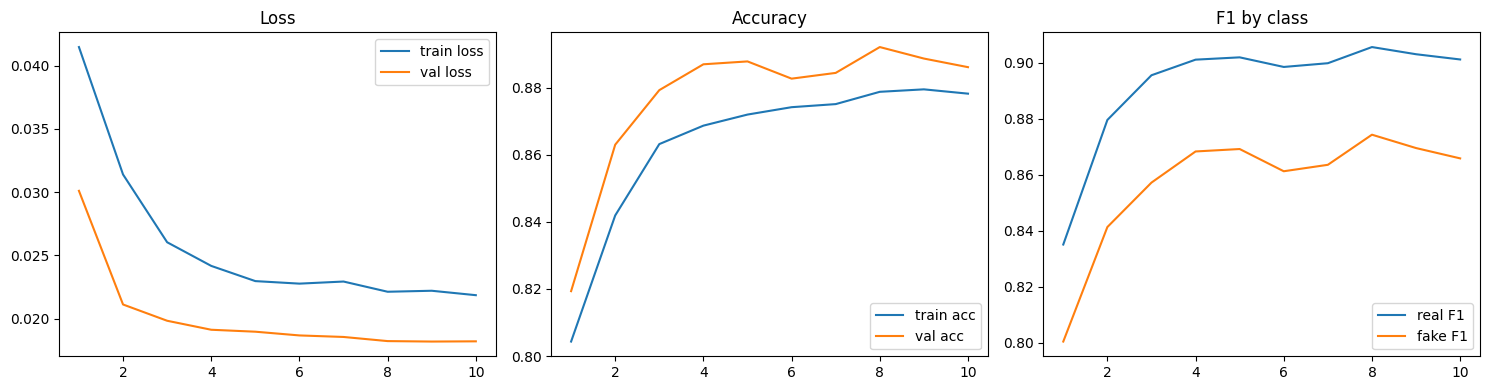

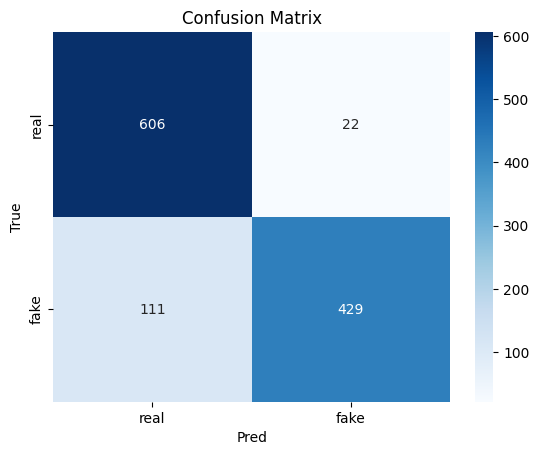

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training(history):
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(15,4))

    # ---- loss / acc 曲线 ----
    plt.subplot(1,3,1)
    plt.plot(epochs, history['train_loss'], label='train loss')
    plt.plot(epochs, history['val_loss'], label='val loss')
    plt.title('Loss'); plt.legend(); plt.grid(False)

    plt.subplot(1,3,2)
    plt.plot(epochs, history['train_acc'], label='train acc')
    plt.plot(epochs, history['val_acc'], label='val acc')
    plt.title('Accuracy'); plt.legend(); plt.grid(False)

    # ---- 每类 F1 ----
    plt.subplot(1,3,3)
    plt.plot(epochs, history['val_f1_0'], label='real F1')
    plt.plot(epochs, history['val_f1_1'], label='fake F1')
    plt.title('F1 by class'); plt.legend(); plt.grid(False)

    plt.tight_layout(); plt.show()

    # ---- 混淆矩阵（最后一 epoch）----
    cm = confusion_matrix(val_true, val_pred)
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['real','fake'],
                yticklabels=['real','fake'],
                cmap='Blues')
    plt.ylabel('True'); plt.xlabel('Pred'); plt.title('Confusion Matrix')
    plt.show()

# 训练完成后调用
plot_training(history)

In [16]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

model.load_state_dict(torch.load(MODEL_SAVE_PATH))
out = evaluate(model, test_loader, criterion, device)
test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=['real', 'fake']))

Test Loss: 0.0188 | Test Acc: 0.8837

Classification Report:
              precision    recall  f1-score   support

        real       0.95      0.85      0.90       701
        fake       0.81      0.93      0.87       468

    accuracy                           0.88      1169
   macro avg       0.88      0.89      0.88      1169
weighted avg       0.89      0.88      0.88      1169



In [17]:
# 1. 纯手写格式，完全控制小数位
print(f"Test Loss: {test_loss:.6f} | Test Acc: {accuracy_score(labels, preds):.6f}")

# 2. 把 classification_report 转成 DataFrame 再改精度
report = classification_report(
    labels, preds,
    target_names=['real', 'fake'],
    output_dict=True          # 返回 dict 而不是字符串
)
df = pd.DataFrame(report).T   # 转置后每一行是一个类别
print(df.round(6))            # 6 位小数，也可以改成 8、10 …

Test Loss: 0.018781 | Test Acc: 0.883661
              precision    recall  f1-score      support
real           0.949126  0.851641  0.897744   701.000000
fake           0.807407  0.931624  0.865079   468.000000
accuracy       0.883661  0.883661  0.883661     0.883661
macro avg      0.878267  0.891632  0.881412  1169.000000
weighted avg   0.892390  0.883661  0.884667  1169.000000


# 五、验证模型架构

## （一）新的模型架构

新的架构为：
flowchart TD
    A[预处理输出<br>统一数据字典] --> B1

    subgraph B1 ["特征提取（双路路径增强）"]
        direction LR
        subgraph TextPath["文本路径 (Text Enhancer)"]
            T1["BERT (CLS)"] -- 768维 --> T3["Self-Attention<br>语义增强"]
            T2["CLIP-Text"] -- 512维 --> T3
        end
        
        subgraph ImagePath["图像路径 (Image Enhancer)"]
            I1["ResNet (Spatial)"] -- 2048维 --> I3["Self-Attention<br>空间增强"]
            I2["CLIP-Vision"] -- 512维 --> I3
        end
    end

    %% 特征提炼阶段
    T3 -- "增强语义向量" --> P1["投影头 Pt"]
    I3 -- "增强视觉向量" --> P2["投影头 Pi"]
    
    %% CLIP 差异路径
    T2 -- "向量" --> C_DIFF["计算差异向量<br>abs(Text - Vis)"]
    I2 -- "向量" --> C_DIFF
    T2 & I2 & C_DIFF --> C1["特征拼合<br>[T, I, Diff]"]
    C1 --> P3["投影头 Pm"]

    %% 相似度控制
    T2 -- "向量" --> W2["计算余弦相似度 S"]
    I2 -- "向量" --> W2
    W2 --> W1["相似度门控<br>Fm' = S * Fm"]
    P3 --> W1

    %% 动态门控融合
    P1 -- "Ft" --> D1["Gating Mechanism<br>动态权重计算"]
    P2 -- "Fi" --> D1
    W1 -- "Fm'" --> D1

    D1 -- "权重 αt, αi, αm" --> E["最终表征求和<br>F_final = αt*Ft + αi*Fi + αm*Fm'"]
    
    E --> F["分类器 (Deep MLP)"] --> G["预测: Real / Fake"]

    %% 注释
    style C_DIFF fill:#f9f,stroke:#333,stroke-width:2px
    style T3 fill:#bbf,stroke:#333
    style I3 fill:#bbf,stroke:#333

In [20]:
print(model)

ECommerceMultimodalModel(
  (resnet_backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
 

## （二）抽样看输入输出

In [18]:
import types

# 重新定义补丁：去掉 return_weights 参数，默认就返回两个值
def extreme_patch(self, bert_input_ids, bert_attention_mask, clip_input_ids, image_tensor):
    # --- 逻辑保持不变 ---
    bert_out = self.bert(input_ids=bert_input_ids, attention_mask=bert_attention_mask)
    bert_cls = bert_out.pooler_output 
    clip_text = F.normalize(self.clip_model.encode_text(clip_input_ids), dim=-1)
    t_concat = torch.cat([bert_cls, clip_text], dim=1).unsqueeze(1)
    t_enhanced, _ = self.text_enhancer(t_concat, t_concat, t_concat)
    Ft = self.proj_text(self.text_norm(t_concat + t_enhanced).squeeze(1))

    resnet_features = self.resnet_backbone(image_tensor).flatten(2).transpose(1, 2)
    resnet_spatial = self.spatial_proj(resnet_features)
    clip_vis = F.normalize(self.clip_model.encode_image(image_tensor), dim=-1)
    v_expanded = clip_vis.unsqueeze(1).expand(-1, resnet_spatial.size(1), -1)
    v_concat = torch.cat([resnet_spatial, v_expanded], dim=2)
    v_enhanced, _ = self.img_enhancer(v_concat, v_concat, v_concat)
    v_final = self.img_norm(v_concat + v_enhanced)
    Fi = self.proj_img(torch.mean(v_final, dim=1))

    sim = F.cosine_similarity(clip_text, clip_vis, dim=1).unsqueeze(1)
    diff = torch.abs(clip_text - clip_vis) 
    Fm = self.proj_clip(torch.cat([clip_text, clip_vis, diff], dim=1))
    Fm_weighted = sim * Fm

    gate_input = torch.cat([Ft, Fi, Fm_weighted], dim=1) 
    alpha = F.softmax(self.gate_fc(gate_input), dim=1) 
    F_final = (alpha[:, 0:1] * Ft + alpha[:, 1:2] * Fi + alpha[:, 2:3] * Fm_weighted)

    logits = self.classifier(F_final)
    # --- 核心改变：强行返回两个值 ---
    return logits, alpha

# 绑定补丁
model.forward = types.MethodType(extreme_patch, model)
print("✅ 暴力 Patch 成功！现在的 new_model 调用后将固定返回 (logits, alpha)")

✅ 暴力 Patch 成功！现在的 new_model 调用后将固定返回 (logits, alpha)


参数名,专业解释,在电商场景下的意义
Sample_ID,样本在验证集中的索引,用于回溯原始数据（查看原始图片和完整评论）。
True_Label,标注的真实类别,0 代表真实评论，1 代表虚假/水军评论。
Pred_Label,模型预测的类别,模型根据文字、图片及图文匹配度给出的判断。
Confidence,预测置信度 (Softmax),模型对这个判断有多大把握。95% 以上说明特征非常明显。
Cosine_Sim_S,图文余弦相似度,"核心指标。范围 [-1, 1]。越接近 0 或负数，代表文字和图片“驴唇不对马嘴”。"
Alpha (α),动态决策权重,模型在做判断时，分别给了“文本、图像、融合特征”多少注意力。

In [19]:
import torch
import torch.nn.functional as F
import pandas as pd

def interpret_model_final_v3(model_in, dataset, device, num_samples=10):
    model_in.eval()
    results = []
    indices = torch.randperm(len(dataset))[:num_samples]
    
    for idx_tensor in indices:
        idx = idx_tensor.item() 
        item = dataset[idx]
        
        b_ids = item['bert_input_ids'].unsqueeze(0).to(device)
        b_mask = item['bert_attention_mask'].unsqueeze(0).to(device)
        c_ids = item['clip_input_ids'].unsqueeze(0).to(device)
        img_t = item['image_tensor'].unsqueeze(0).to(device)
        label = item['label'].item()
        
        with torch.no_grad():
            # 1. 计算相似度
            clip_text = F.normalize(model_in.clip_model.encode_text(c_ids), dim=-1)
            clip_vis = F.normalize(model_in.clip_model.encode_image(img_t), dim=-1)
            sim = F.cosine_similarity(clip_text, clip_vis, dim=1).item()

            # 2. 调用模型（注意：这里不传 return_weights 参数了）
            # 因为补丁已经改写了输出格式
            logits, alpha = model_in(b_ids, b_mask, c_ids, img_t)
            
            probs = F.softmax(logits, dim=1)
            pred = torch.argmax(logits, dim=1).item()
            a_t, a_i, a_m = alpha[0].cpu().numpy()

        results.append({
            "Sample_ID": idx,
            "Text": dataset.df.iloc[idx]['text_clean'][:25] + "...",
            "True": "Fake" if label == 1 else "Real",
            "Pred": "Fake" if pred == 1 else "Real",
            "Conf": f"{probs[0][pred].item():.1%}",
            "Sim_S": round(sim, 4),
            "α_Text": round(a_t, 4), 
            "α_Img": round(a_i, 4),
            "α_Fusion": round(a_m, 4)
        })
        
    return pd.DataFrame(results)

# 运行
df_final = interpret_model_final_v3(model, val_loader.dataset, device, num_samples=10)
display(df_final)

,Sample_ID,Text,True,Pred,Conf,Sim_S,α_Text,α_Img,α_Fusion
0,417,家里老人小孩都用着，选了这款产品，客服讲解得挺细致...,Fake,Fake,93.6%,0.2130,0.5252,0.1419,0.3329
1,90,做了超多功课才选中的Viva鱼油，到手直接被品质圈...,Fake,Fake,77.6%,0.2027,0.4211,0.1913,0.3876
2,855,JM面膜简直就是水润的代名词，用起来水水的，特别舒...,Fake,Real,52.4%,0.1959,0.2381,0.2386,0.5233
3,825,很好，维稳一级棒。没有烂脸不是油痘肌不做医美，所以...,Fake,Real,63.9%,0.2130,0.1426,0.2073,0.6501
4,349,这款后Whoo天气丹PRO光耀焕活紧颜水乳护肤品7...,Fake,Fake,73.9%,0.2191,0.3844,0.1831,0.4326
5,653,其实我天生肤质就挺好的，一直用大红瓶，前段时间突然...,Fake,Fake,53.9%,0.2177,0.2564,0.2137,0.5299
6,69,成分很安全。我考察很久就觉得它很好，很少感冒之类的...,Real,Real,65.6%,0.2167,0.1188,0.2060,0.6752
7,0,家里老人小孩都用着，选了这款钙，整体看着挺靠谱的，...,Fake,Fake,88.1%,0.2130,0.4186,0.1721,0.4093
8,808,看着就是正品！我先试用两个月，到时候追评给大家看效...,Fake,Fake,61.1%,0.2201,0.2521,0.1869,0.5609
9,1128,整体评价 很滋润 买了三罐啦！！物美价廉的面霜还能...,Real,Fake,50.5%,0.2013,0.2336,0.2299,0.5365
